In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_qsphere

# Using Aer's statevector simulator for phase verification
simulator = Aer.get_backend('aer_simulator')

In [18]:
def build_GHZ_circuit(n):
    """Builds a GHZ state circuit for n qubits."""
    circuit = QuantumCircuit(n)
    circuit.h(0)  # Apply Hadamard to the first qubit
    for i in range(1, n):
        circuit.cx(i-1,i)  # Apply CNOT from the first qubit to the others
    return circuit

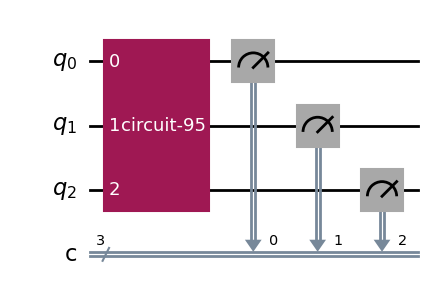

In [26]:
n=int(input("Enter the number of qubits for the GHZ state: "))
qc=QuantumCircuit(n,n)
circuit=build_GHZ_circuit(n)
qc.append(circuit, range(n))
qc.measure(range(n), range(n))
qc.draw('mpl',filename='ghz_circuit.png')


# qc = qc.compose(circuit, range(n))
# qc.measure(range(n), range(n))
# qc.draw('mpl',filename='ghz_circuit_meas.png')



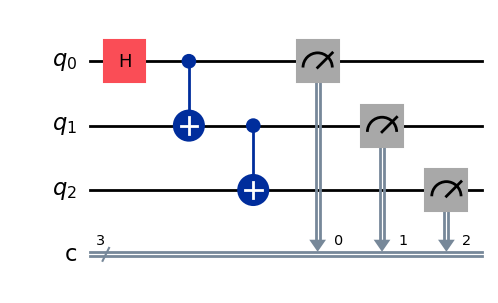

In [27]:
qc1=QuantumCircuit(n,n)
circuit=build_GHZ_circuit(n)
qc1.compose(circuit, range(n), inplace=True)
qc1.measure(range(n), range(n))
qc1.draw('mpl',filename='ghz_circuit_meas.png')


{'000': 510, '111': 514}


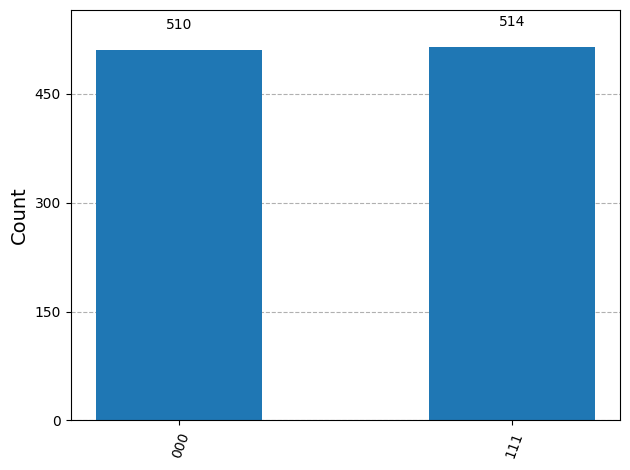

In [29]:
# Histogram of results
qc_transpiled = transpile(qc, simulator)
result = simulator.run(qc_transpiled, shots=1024).result()
counts = result.get_counts(qc_transpiled)
print(counts)
display(plot_histogram(counts))

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


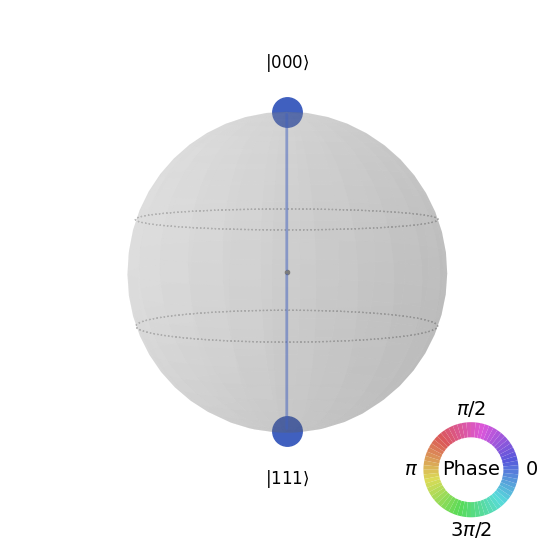

In [31]:
qc_no_measure=QuantumCircuit(n)
qc_no_measure.compose(circuit, range(n), inplace=True)
statevector = Statevector.from_instruction(qc_no_measure)
print(statevector)
display(plot_state_qsphere(statevector))